# EDA

Usamos la librería `yifinance`. Esta librería de código abierto para Python nos permite descargar datos financieros históricos y en tiempo real directamente desde Yahoo Finance. Entre otros, podemos obtener información sobre una gran variedad de activos financieros, incluyendo:
- Acciones (p. ej., AAPL, TSLA, MSFT).

- ETFs y Fondos de inversión.

- Criptomonedas (p. ej., BTC-USD).

- Divisas (Forex) e índices bursátiles.

Para este proyecto, usaremos el ETF que sigue al índice S&P500, cuyo ticker es SPY

# 1. Importación de librerías y carga de datos

Primero, descargamos el histórico del SPY. Tomaremos datos desde el año 2000 para incluir varios ciclos económicos (la crisis Dot-com, la de 2008, y el COVID-19), lo cual es ideal para que los modelos aprendan sobre regímenes de alta volatilidad.

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import norm

# Configuración visual
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

# Carga de Datos
ticker = "SPY"
df = yf.download(ticker, start="2000-01-01", end="2026-04-15", auto_adjust=False)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0) 

# Nos quedamos con el 'Close' para evitar saltos por dividendos/splits
df = df[['Close']].copy()
df.rename(columns={'Close': 'Price'}, inplace=True)

df.tail()

[*********************100%***********************]  1 of 1 completed


Price,Price
Date,
2026-04-08,676.010010
2026-04-09,679.909973
2026-04-10,679.460022
2026-04-13,686.099976
2026-04-14,694.460022


# 2. Feature Engineering

Aquí creamos nuestras variables clave. El Feature Engineering es el proceso de transformar datos en bruto en variables (características) que faciliten que un modelo de aprendizaje automático (Machine Learning) aprenda de forma más eficiente y precisa.\
Para que los modelos (especialmente los de Deep Learning como LSTM y Transformers) funcionen correctamente, no basta con darles el precio de cierre. El Feature Engineering es lo que permite que el modelo "entienda" la dinámica del mercado.\

Las variables que necesitaremos son las siguientes:
- Retornos Logarítmicos ($Log\ Returns$): En finanzas, rara vez trabajamos con precios nominales porque no son estacionarios (tienden a subir o bajar en el tiempo, lo que rompe las asunciones estadísticas). Usamos retornos logarítmicos por varias razones:
    - Aditividad Temporal: El retorno logarítmico de un periodo largo es simplemente la suma de los retornos de los subperiodos. Esto es vital para redes neuronales que analizan secuencias. $$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$
    - Normalización de Magnitud: Permiten comparar variaciones del S&P 500 cuando cotizaba a 1,000 puntos en el año 2000 frente a los 5,000+ actuales. Los retornos son porcentuales y, por tanto, comparables a través de las décadas.
    - Simetría: Los retornos logarítmicos tratan las subidas y bajadas de forma más simétrica que los retornos simples, lo cual facilita la convergencia de los algoritmos de optimización (como Adam o SGD) en las redes neuronales.
- Volatilidad Realizada Anualizada ($RV$): La volatilidad es "latente" (no se ve, se infiere). Para que un modelo de Deep Learning aprenda a predecirla, necesitas darle un target (objetivo) o una referencia histórica clara.
    - El Proxy de la Verdad: La Volatilidad Realizada (calculada, por ejemplo, como la desviación estándar de los retornos en una ventana móvil de 21 días) actúa como la etiqueta que el modelo intenta predecir.
    - Anualización: Los modelos de Option Pricing (como Black-Scholes) requieren la volatilidad en términos anuales. Multiplicar la volatilidad diaria por $\sqrt{252}$ (días laborables en un año) estandariza la medida. $$\sigma_{ann} = \sigma_{daily} \times \sqrt{252}$$
    - Memoria del Modelo: Al darle la volatilidad pasada como feature, el LSTM puede detectar patrones de volatility clustering (si ayer hubo mucha volatilidad, hoy probablemente también la haya).
- Variables Exógenas: MACD y RSI. Aquí es donde los modelos de Deep Learning superan al GARCH. Mientras que el GARCH solo mira retornos pasados, el LSTM y el Transformer pueden usar indicadores de "momentum" y "sentimiento" para anticipar cambios de régimen.
    - RSI (Relative Strength Index):
        - Detección de Reversión: El RSI mide la velocidad y el cambio de los movimientos de precios. Un RSI por encima de 70 (sobrecompra) o por debajo de 30 (sobreventa) a menudo precede a un aumento en la volatilidad debido a correcciones del mercado o rebotes técnicos.
        - Señal de Estrés: Los niveles extremos de RSI suelen coincidir con picos de pánico o euforia, momentos donde la volatilidad del S&P 500 se dispara.
    - MACD (Moving Average Convergence Divergence):
        - Identificación de Tendencia: El MACD ayuda al modelo a entender si el mercado está en una tendencia clara o en un rango lateral.
        - Cruces de Volatilidad: Un cruce de líneas en el MACD puede indicar un cambio en la fuerza del mercado. Para un Transformer, esto es una señal de que la estructura de la serie temporal está cambiando, lo que suele venir acompañado de un cambio en la desviación estándar (volatilidad).

Así, tenemos que, en resumen:
1. Para el GARCH: Solo usará los Retornos Logarítmicos. Es un modelo "puro" que busca la heterocedasticidad en los residuos de esos retornos.
2. Para el LSTM: Se beneficia de la Volatilidad Realizada y los retornos. Al ser una red recursiva, "recuerda" cómo estas variables evolucionaron en los últimos días de la secuencia.
3. Para el Transformer: Es donde el RSI y el MACD brillan. El mecanismo de Attention puede aprender que, por ejemplo, "cuando el RSI está en 85 Y el retorno es negativo, la volatilidad tiende a explotar 3 días después". El Transformer crea correlaciones cruzadas entre estas variables que un modelo lineal jamás vería.

## 2.1. Retornos logarítmicos ($r_t = \ln(P_t / P_{t-1})$) 

Los retornos logarítmicos nos benefician por sus propiedades aditivas y estadísticas. 

In [4]:
# Usamos log-retornos en lugar de retornos simples por sus mejores propiedades estadísticas
df['Log_Returns'] = np.log(df['Price'] / df['Price'].shift(1))

La siguiente gráfica es una comparativa de la distribución real de los log-retornos del S&P500 (histograma azul + KDE) frente a una distribución normal teórica con los mismos parámetros (curva roja, $\mu$=0.0002, $\sigma$=0.0124):

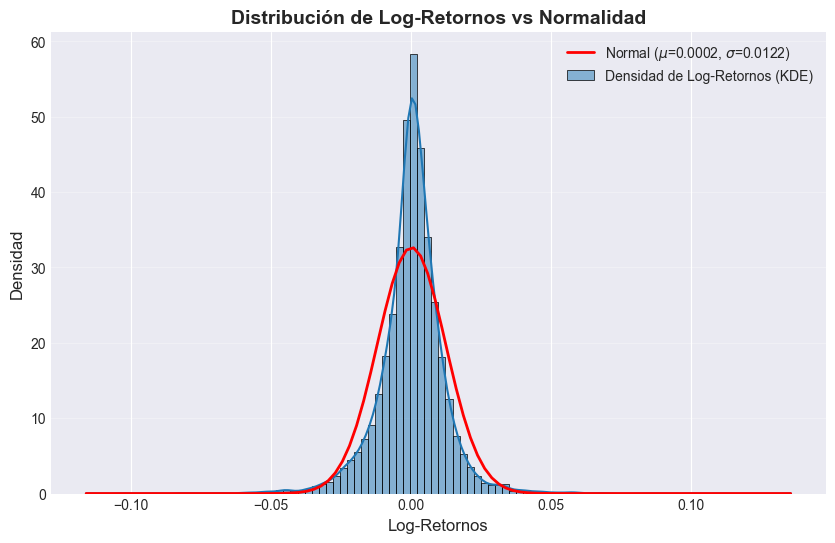

In [5]:
plt.figure(figsize=(10, 6))

# Graficar Histograma + KDE (Curva de Densidad)
# Usamos stat="density" para que el área del histograma sume 1
sns.histplot(df['Log_Returns'].dropna(), kde=True, bins=100, color='#1f77b4', 
             stat="density", label='Densidad de Log-Retornos (KDE)', alpha=0.5)

# Superponer una Distribución Normal teórica para comparación
mu, std = df['Log_Returns'].mean(), df['Log_Returns'].std()
x = np.linspace(df['Log_Returns'].min(), df['Log_Returns'].max(), 100)
p = norm.pdf(x, mu, std)

plt.plot(x, p, 'r', linewidth=2, label=f'Normal ($\mu$={mu:.4f}, $\sigma$={std:.4f})')

# Etiquetas
plt.title('Distribución de Log-Retornos vs Normalidad', fontsize=14, fontweight='bold')
plt.xlabel('Log-Retornos', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

Hallazgos:
- Leptocurtosis: La distribución real es mucho más puntiaguda en el centro y tiene colas más gruesas que la normal. Esto significa que los retornos cercanos a cero ocurren con mayor frecuencia de lo que predice la normal y que los eventos extremos (retornos de ±0.05 o más) ocurren con más probabilidad real que la teórica.
- La normal subestima el riesgo: La curva roja es más "ancha y baja" que la distribución real, lo que implica que modelos basados en normalidad infravaloran la probabilidad de pérdidas severas.
- Asimetría leve: El histograma muestra una ligera asimetría negativa (cola izquierda algo más extendida), lo que indica que las caídas extremas son marginalmente más frecuentes que las subidas extremas, como vemos con el siguiente cálculo:

In [6]:
asimetria = df['Log_Returns'].skew()
asimetria

np.float64(-0.2043520770224199)

En definitiva, asumir normalidad en este caso llevaría a una gestión de riesgo deficiente, especialmente en situaciones de mercado extremas (crisis, crashes).

## 2.2. Varaible Target: Volatilidad Realizada anualizada

In [7]:
# Calculamos la desviación estándar móvil de 21 días (aprox. 1 mes de trading)
# Calculamos la desviación estándar std() de los rendimientos de estos 21 rendimientos logarítmicos.
# Multiplicamos por la raíz cuadrada de 252 para anualizar la volatilidad
window = 21
df['Realized_Vol'] = df['Log_Returns'].rolling(window=window).std() * np.sqrt(252)

Vamos a graficar la volatilidad realizada para visualizar dos conceptos clave:
1. Visualización del "Volatility Clustering": En el gráfico inferior (rojo), se observa que la volatilidad no es ruido blanco aleatorio. Hay periodos donde la línea se mantiene baja y estable, y periodos donde presenta picos y se mantiene alta durante un tiempo. Esto confirma visualmente que la volatilidad del S&P 500 tiene memoria, lo cual justifica el uso de modelos como GARCH y LSTM.
2. Identificación de Regímenes de Mercado: Al comparar el precio (azul) con la volatilidad (rojo), observamos el Leverage Effect:
    - Cuando el precio cae bruscamente (crisis de 2008 o 2020, representadas en los picos del gráfico), la volatilidad se dispara verticalmente.
    - En mercados alcistas lentos, la volatilidad suele comprimirse.


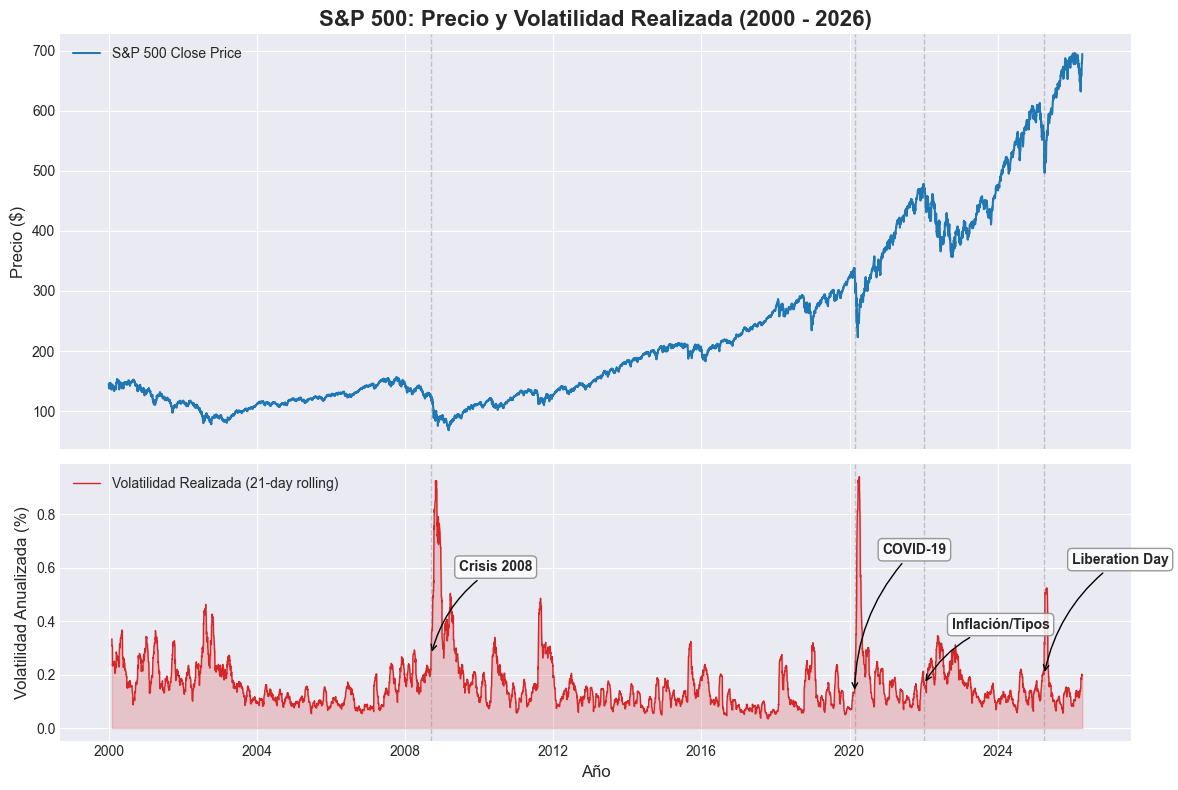

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [3, 2]}, figsize=(12, 8))

# Gráfico Superior: Precio de Cierre
ax1.plot(df.index, df['Price'], color='#1f77b4', lw=1.5, label='S&P 500 Close Price')
ax1.set_title('S&P 500: Precio y Volatilidad Realizada (2000 - 2026)', fontsize=16, fontweight='bold')
ax1.set_ylabel('Precio ($)', fontsize=12)
ax1.legend(loc='upper left')

# Gráfico Inferior: Volatilidad Realizada
ax2.plot(df.index, df['Realized_Vol'], color='#d62728', lw=1, label='Volatilidad Realizada (21-day rolling)')
ax2.fill_between(df.index, df['Realized_Vol'], color='#d62728', alpha=0.2)
ax2.set_ylabel('Volatilidad Anualizada (%)', fontsize=12)
ax2.set_xlabel('Año', fontsize=12)
ax2.legend(loc='upper left')


events = {
    '2008-09-15': 'Crisis 2008',
    '2020-02-20': 'COVID-19',
    '2022-01-03': 'Inflación/Tipos',
    '2025-04-02': 'Liberation Day'  
}


# Definimos diferentes alturas para que no choquen si están cerca
# (offset_x, offset_y)
staggered_offsets = [(20, 60), (20, 100), (20, 40), (20, 80)]  
for i, (date, label) in enumerate(events.items()):
    d = pd.to_datetime(date)
    if d in df.index:
        y_val = df.loc[d, 'Realized_Vol']
        
        # líneas verticales 
        ax1.axvline(d, color='gray', linestyle='--', alpha=0.4, lw=1)
        ax2.axvline(d, color='gray', linestyle='--', alpha=0.4, lw=1)
        
        ax2.annotate(
            label, 
            xy=(d, y_val), 
            xytext=staggered_offsets[i % len(staggered_offsets)], # Rotar entre posiciones
            textcoords='offset points',
            arrowprops=dict(
                arrowstyle='->', 
                connectionstyle="arc3,rad=.2", # Flecha curva para evitar tapar la línea
                color='black'
            ),
            fontsize=10, 
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8) # Fondo para leer mejor
        )

plt.tight_layout()
plt.show()

## 2.3. Variables Exógenas (indicadores técnocos básicos)

El **MACD** (Moving Average Convergence Divergence) es un indicador que intenta medir la tendencia (dirección) y el momentum (fuerza) del precio. Para calcularlo, aplicamos una media movil exponencial EMA. A diferencia de una media normal (donde todos los días valen lo mismo), la exponencial le da más peso a los precios de ayer y de hoy que a los de hace dos semanas.
- Si MACD>0 La media rápida está por encima de la lenta. El precio está subiendo con fuerza (impulso alcista).
- Si MACD<0 La media rápida está por debajo de la lenta. El precio está cayendo con fuerza (impulso bajista).
- Si el MACD cruza el nivel 0 significa que las dos medias se han cortado, lo que suele interpretarse como una señal de cambio de tendencia.

In [9]:
# MACD
# En lugar de variables sueltas (exp1, exp2), las guardamos directamente
# como columnas del DataFrame. Así forzamos a que tengan el mismo índice y longitud para poder graficarlas.
df['EMA_12'] = df['Price'].ewm(span=12, adjust=False).mean() # span=12 "reacciona" más rápido a cambios en el precio
df['EMA_26'] = df['Price'].ewm(span=26, adjust=False).mean() # span=26 es más pesada y estable. Representa la tendencia a más largo plazo.
df['MACD'] = df['EMA_12'] - df['EMA_26'] # El MACD no es más que la distancia entre esas dos medias.



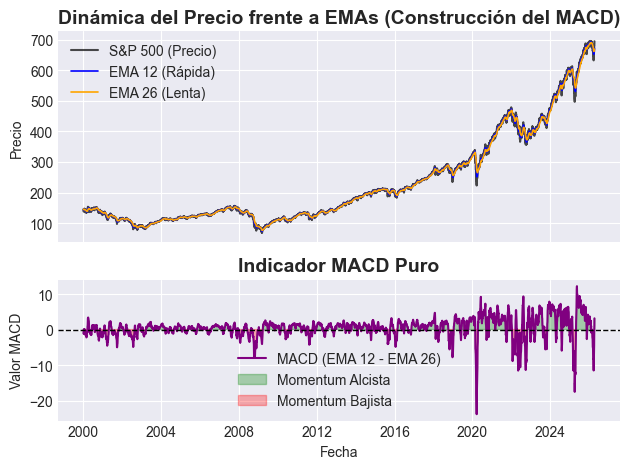

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [3, 2]})

# --- Panel Superior: Precio y EMAs ---
ax1.plot(df.index, df['Price'], color='black', lw=1.5, label='S&P 500 (Precio)', alpha=0.7)
ax1.plot(df.index, df['EMA_12'], color='blue', lw=1.2, label='EMA 12 (Rápida)')
ax1.plot(df.index, df['EMA_26'], color='orange', lw=1.2, label='EMA 26 (Lenta)')
ax1.set_title('Dinámica del Precio frente a EMAs (Construcción del MACD)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Precio')
ax1.legend(loc='upper left')

# --- Panel Inferior: El Oscilador MACD ---
ax2.plot(df.index, df['MACD'], color='purple', lw=1.5, label='MACD (EMA 12 - EMA 26)')

# Rellenar el área (usando .squeeze() por si la columna viene como DataFrame 2D de yfinance)
macd_values = df['MACD'].squeeze() 
ax2.fill_between(df.index, macd_values, 0, where=(macd_values >= 0), color='green', alpha=0.3, label='Momentum Alcista')
ax2.fill_between(df.index, macd_values, 0, where=(macd_values < 0), color='red', alpha=0.3, label='Momentum Bajista')

# Línea de Cero
ax2.axhline(0, color='black', lw=1, linestyle='--')
ax2.set_title('Indicador MACD Puro', fontsize=14, fontweight='bold')
ax2.set_ylabel('Valor MACD')
ax2.set_xlabel('Fecha')
ax2.legend(loc='best')

plt.tight_layout()
plt.show()

Observamos claramente lo siguiente:
- **2000 - 2003**: El MACD oscila en torno a cero con ligero sesgo bajista. La caída es gradual, sin un colapso brusco del indicador, lo que refleja un deterioro sostenido del momentum.
- **2008 - 2009**: El MACD cae a $\sim −22$, el mínimo histórico de toda la serie. La separación entre EMA12 y EMA26 fue extrema y prolongada, señal de una tendencia bajista de altísima intensidad. La recuperación posterior es rápida y clara cuando el MACD cruza de nuevo al territorio positivo.
- **2010 - 2019**: El MACD se mantiene predominantemente en zona verde (positiva), con oscilaciones moderadas. Confirma una tendencia alcista estructural con momentum sostenido. Los retrocesos a zona roja son breves y superficiales.
- **2020 (Covid-19)**: Caída brusca del MACD a valores muy negativos ($\sim −22$), pero la recuperación es casi vertical, la más rápida de toda la serie. Esto refleja la velocidad sin precedentes con que la EMA12 volvió a superar a la EMA26 tras el rebote.
- **2022 -2024 (inflación y tipos)**: Mayor volatilidad del MACD que en cualquier período post-crisis anterior. Las oscilaciones son amplias entre $+8$ y $−5$, cruzando la línea cero repetidamente. Señal de un mercado con momentum inestable, sin tendencia clara y sostenida.
- **2024 - Presente**: El MACD llega a valores de $+10$ a $+12$, los más altos de toda la serie histórica de 25 años. Coincide con el boom de IA y tecnología que impulsó al mercado en 2023–2024

El **RSI** es uno de los osciladores más utilizados en finanzas. Su objetivo es medir la velocidad y el cambio de los movimientos de precios para determinar si un activo está "sobrecomprado" o "sobrevendido".

- RSI > 70 (Sobrecompra): El precio ha subido muy rápido. Podría estar "caro" y pronto podría haber una corrección o aumentar la volatilidad.
- RSI < 30 (Sobreventa): El precio ha caído muy rápido. Podría estar "barato" o a punto de rebotar.

Cuando el RSI llega a extremos (por encima de 70 o por debajo de 30), el mercado se pone "nervioso". Los inversores empiezan a cerrar posiciones o a comprar masivamente, lo que suele ir acompañado de un pico en la volatilidad. 

In [11]:
# RSI (Relative Strength Index) - 14 días
delta = df['Price'].diff() # diferencia de precio entre el día de hoy y el de ayer. Si delta > 0 el precio subió y viceversa
# Separamos los movimientos alcistas de los bajistas en un periodo de 14 días:
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean() # Filtra solo los valores positivos (subidas). Si hubo una caída, pone un 0. Luego saca el promedio de esos 14 días.
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean() # Filtra solo los valores negativos (caídas), les cambia el signo para que sean positivos y saca el promedio.

# Relative Strength. El RS es simplemente la proporción entre cuánto sube el activo frente a cuánto baja.
rs = gain / loss

# "normalizamos" el resultado para que siempre esté en un rango de 0 a 100
df['RSI'] = 100 - (100 / (1 + rs))

# Eliminamos los valores nulos generados por las ventanas móviles
df.dropna(inplace=True)



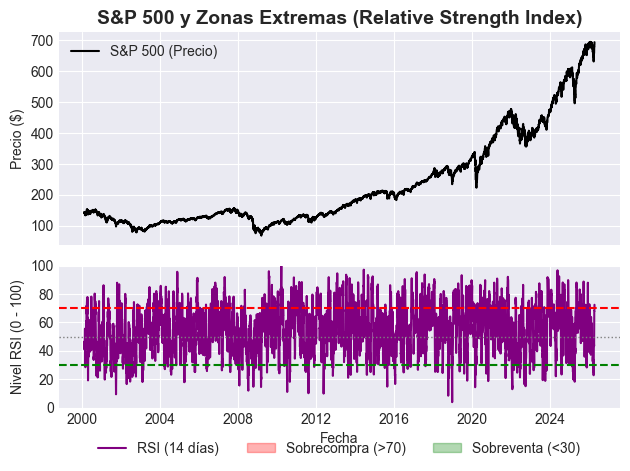

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [3, 2]})

# --- Panel Superior: Precio ---
ax1.plot(df.index, df['Price'], color='black', lw=1.5, label='S&P 500 (Precio)')
ax1.set_title('S&P 500 y Zonas Extremas (Relative Strength Index)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Precio ($)')
ax1.legend(loc='upper left')

# --- Panel Inferior: Oscilador RSI ---
ax2.plot(df.index, df['RSI'], color='purple', lw=1.5, label='RSI (14 días)')

# Líneas de referencia estándar del RSI
ax2.axhline(70, color='red', lw=1.5, linestyle='--')
ax2.axhline(30, color='green', lw=1.5, linestyle='--')
ax2.axhline(50, color='gray', lw=1, linestyle=':') # Línea central (neutralidad)


rsi_values = df['RSI'].squeeze()
ax2.fill_between(df.index, rsi_values, 70, where=(rsi_values >= 70), color='red', alpha=0.3, label='Sobrecompra (>70)')
ax2.fill_between(df.index, rsi_values, 30, where=(rsi_values <= 30), color='green', alpha=0.3, label='Sobreventa (<30)')

ax2.set_ylabel('Nivel RSI (0 - 100)')
ax2.set_xlabel('Fecha')
ax2.set_ylim(0, 100) # El RSI siempre va de 0 a 100

# Leyenda
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)

plt.tight_layout()
plt.show()

Observamos lo siguiente:
- **2000 – 2003**: El RSI cae repetidamente a zona de sobreventa (<30), confirmando la tendencia bajista prolongada. Es uno de los pocos períodos donde el RSI toca consistentemente niveles extremos bajos.
- **2008 – 2009**: El RSI registra caídas profundas, tocando valores cercanos a 0–10, niveles de sobreventa extrema que reflejan el pánico vendedor sin precedentes.
- **2010 – 2019**: Patrón muy característico. El RSI raramente baja de 30 y oscila predominantemente entre 40 y 80. Las caídas a sobreventa son fugaces y rápidamente corregidas. Un mercado alcista "sano".
- **2020 (Covid-19)**: Caída instantánea a sobreventa extrema seguida de una recuperación igual de violenta hacia sobrecompra.  



Hacemos una gráfica conjunta:

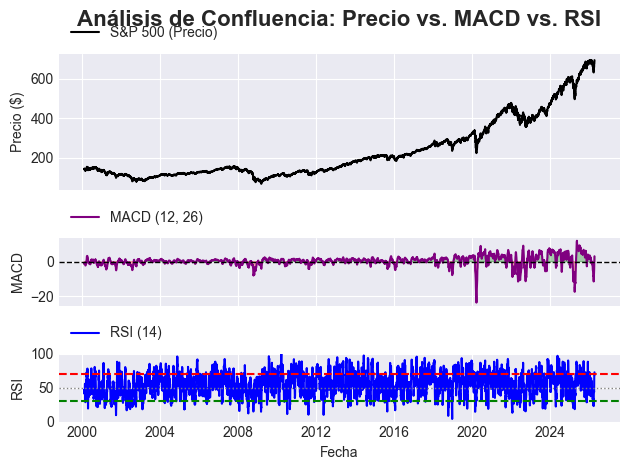

In [13]:
macd_values = df['MACD'].squeeze()
rsi_values = df['RSI'].squeeze()


fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, gridspec_kw={'height_ratios': [3, 1.5, 1.5]})

# --- PANEL 1: PRECIO ---
ax1.plot(df.index, df['Price'], color='black', lw=1.5, label='S&P 500 (Precio)')
ax1.set_title('Análisis de Confluencia: Precio vs. MACD vs. RSI', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('Precio ($)')
ax1.legend(loc='lower left', bbox_to_anchor=(0, 1.01), frameon=False, fontsize=10)

# --- PANEL 2: MACD ---
ax2.plot(df.index, macd_values, color='purple', lw=1.5, label='MACD (12, 26)')
ax2.fill_between(df.index, macd_values, 0, where=(macd_values >= 0), color='green', alpha=0.3)
ax2.fill_between(df.index, macd_values, 0, where=(macd_values < 0), color='red', alpha=0.3)
ax2.axhline(0, color='black', lw=1, linestyle='--')
ax2.set_ylabel('MACD')
ax2.legend(loc='lower left', bbox_to_anchor=(0, 1.01), frameon=False, fontsize=10)

# --- PANEL 3: RSI ---
ax3.plot(df.index, rsi_values, color='blue', lw=1.5, label='RSI (14)')
ax3.axhline(70, color='red', lw=1.5, linestyle='--')
ax3.axhline(30, color='green', lw=1.5, linestyle='--')
ax3.axhline(50, color='gray', lw=1, linestyle=':')
ax3.fill_between(df.index, rsi_values, 70, where=(rsi_values >= 70), color='red', alpha=0.2)
ax3.fill_between(df.index, rsi_values, 30, where=(rsi_values <= 30), color='green', alpha=0.2)
ax3.set_ylabel('RSI')
ax3.set_xlabel('Fecha')
ax3.set_ylim(0, 100)
ax3.legend(loc='lower left', bbox_to_anchor=(0, 1.01), frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

# 3. Prueba de Estacionariedad (Test de Augmented Dickey-Fuller)

- **Estacionariedad**: Una serie temporal es estacionaria si sus propiedades estadísticas se mantienen constantes a lo largo del tiempo. Esto significa que no importa en qué momento del tiempo observes la serie (año 2000, 2010 o 2024), su comportamiento subyacente es el mismo.\
Matemáticamente, para que una serie sea estrictamente estacionaria, debe cumplir tres condiciones:
    - Media constante: La serie no tiene una tendencia alcista ni bajista. Oscila siempre alrededor de un mismo valor.
    - Varianza (incondicional) constante: La amplitud de las oscilaciones no crece de forma descontrolada hacia el infinito con el paso del tiempo. (GARCH modela la varianza condicional a corto plazo, pero asume que la varianza a largo plazo es estable).
    - Autocovarianza constante: La relación entre un dato y su dato anterior ($t$ y $t-1$) es la misma hoy que hace 10 años.
    
Un buen ejemplo para entender lo anterior es el siguiente:
- Serie NO Estacionaria (El Precio del S&P 500): En el año 2000 valía $\sim 1,400$ puntos. Hoy vale más de $5,000$. Su media cambia (crece), por lo que es imposible predecir su valor exacto de mañana basándose únicamente en su media histórica.
- Serie estacionaria (El Retorno Diario del S&P 500): Un retorno del $+1\%$ significaba lo mismo en el año 2000 que en el año 2024. Su media a largo plazo es prácticamente $0$.

Para que los modelos estadísticos funcionen correctamente, necesitamos que la serie de retornos sea estacionaria (media y varianza constantes a lo largo del tiempo, sin tendencias a largo plazo).\
Si introducimos directamente el precio de cierre (no estacionario) en una red neuronal o en un GARCH, ocurrirán varios problemas graves que arruinarán el proyecto:
- Regresión Espuria (Spurious Regression): Los modelos estadísticos pueden encontrar correlaciones falsas. Si entrenamos un modelo con dos series que simplemente suben con el tiempo (ej. el precio del S&P 500 y el precio de los aguacates), el modelo creerá erróneamente que una predice a la otra, cuando en realidad ambas solo comparten el efecto de la inflación o el crecimiento económico.
- Imposibilidad de Generalizar (Machine Learning): Las redes LSTM y los Transformers necesitan que los datos de *entrenamiento* y los de *test* provengan de la misma distribución estadística. Si el S&P 500 en los datos de entrenamiento oscila entre $1,000$ y $3,000$, y en los datos de *test* está en $5,000$, la red neuronal fallará estrepitosamente porque nunca ha visto esos números. Al convertir precios a retornos, normalizamos toda la serie en porcentajes que la red sí puede comparar.
- Requisito Matemático del GARCH: La econometría clásica es estricta. Las ecuaciones matemáticas detrás del modelo GARCH y ARMA colapsan (no convergen en una solución) si la serie introducida no es estacionaria.

**Test de de Augmented Dickey-Fuller (ADF)**:\
El ADF Test es la prueba estadística estándar que usamos en Python (mediante la librería statsmodels) para demostrar matemáticamente que nuestra serie ha dejado de ser el precio (no estacionaria) y se ha convertido en retornos válidos (estacionaria). Es un contraste de hipótesis. El test busca la presencia de una "raíz unitaria" (un término matemático que indica que los shocks en la serie tienen un efecto permanente y, por tanto, tiene tendencia):
- **Hipótesis Nula** ($H_0$): La serie temporal tiene una raíz unitaria. Es decir, es **NO ESTACIONARIA**.
- **Hipótesis Alternativa** ($H_1$): La serie temporal no tiene una raíz unitaria. Es decir, **es ESTACIONARIA**.

In [14]:
# Test ADF sobre los Log-Retornos
print("--- Resultados del Test Augmented Dickey-Fuller (ADF) ---")
adf_result = adfuller(df['Log_Returns'])
print(f'ADF Statistic: {adf_result[0]:.4f}')
print(f'p-value: {adf_result[1]:.4f}')

if adf_result[1] < 0.05:
    print("Conclusión: Rechazamos la hipótesis nula. La serie de retornos es ESTACIONARIA.")
else:
    print("Conclusión: No podemos rechazar la hipótesis nula. La serie NO es estacionaria.")

--- Resultados del Test Augmented Dickey-Fuller (ADF) ---
ADF Statistic: -20.3431
p-value: 0.0000
Conclusión: Rechazamos la hipótesis nula. La serie de retornos es ESTACIONARIA.


## 4. Efectos ARCH (Autocorrelación de los retornos al cuadrado)

En la econometría clásica (como las regresiones lineales simples), siempre se asume una regla de oro: la homocedasticidad (varianza de los errores se mantiene constante a lo largo del tiempo). Sin embargo, en finanzas, esta premisa se rompe. Aquí es donde entra ARCH: Autoregressive Conditional Heteroskedasticity (Heterocedasticidad Condicional Autorregresiva). \
**ARCH**:

- **Heterocedasticidad**: Significa que la varianza (volatilidad) no es constante. Cambia con el tiempo. El S&P 500 no se mueve igual de violento en 2017 que en marzo de 2020.
- **Condicional**: La volatilidad de hoy no es un valor aleatorio; está condicionada a la información reciente. Específicamente, depende de lo que pasó en el pasado inmediato.
- **Autorregresiva**: La volatilidad se predice a sí misma usando sus propios valores pasados o los errores (retornos) pasados.

En definitiva, tener "efectos ARCH" es simplemente el nombre estadístico formal para el Volatility Clustering (Agrupamiento de Volatilidad). Significa que los movimientos grandes de los precios tienden a ser seguidos por movimientos grandes (ya sean subidas o bajadas), y los movimientos pequeños tienden a ser seguidos por movimientos pequeños. *El mercado tiene memoria a corto plazo para el pánico y la euforia.* Si el S&P 500 no tuviera efectos ARCH (es decir, si su volatilidad fuera ruido aleatorio constante), el modelo GARCH no serviría para nada; las redes LSTM y Transformers no tendrían ningún patrón secuencial de volatilidad que aprender; el Pricing de Opciones sería facilísimo, pues solo tendríamos que tener en cuenta la volatilidad histórica promedio a 20 años en la fórmula de Black-Scholes y siempre acertaríamos.

Veamos los efectos ARCH.\
Debemos elevar los log-retornos al cuadrado para medir la magnitud de los movimientos independientemente del signo, es decir, la volatilidad.

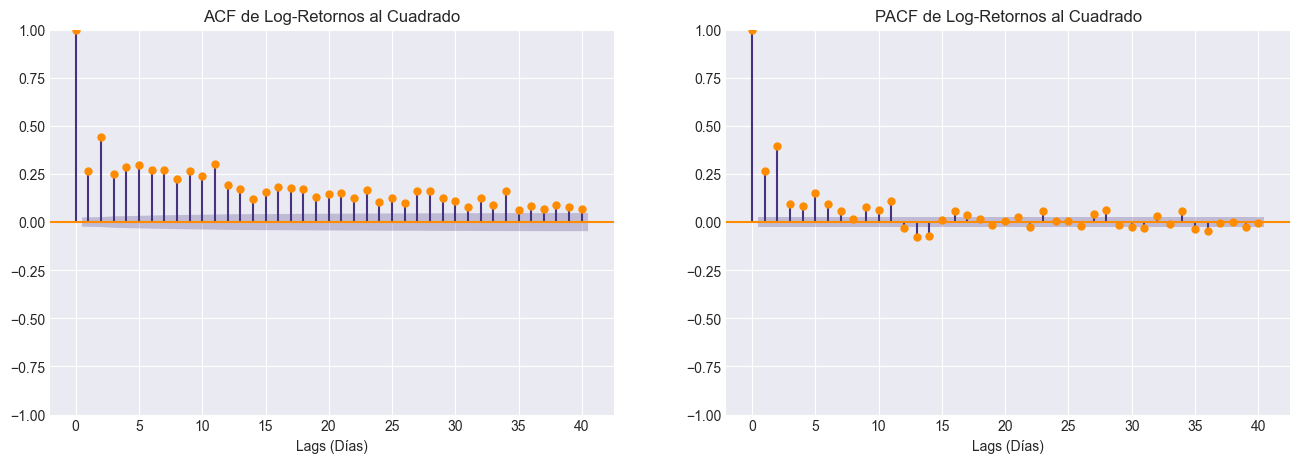

In [15]:
# Calculamos los retornos al cuadrado
df['Squared_Returns'] = df['Log_Returns'] ** 2

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF (Autocorrelation Function)
plot_acf(df['Squared_Returns'], lags=40, ax=axes[0], color='darkorange')
axes[0].set_title('ACF de Log-Retornos al Cuadrado')
axes[0].set_xlabel('Lags (Días)')

# PACF (Partial Autocorrelation Function)
plot_pacf(df['Squared_Returns'], lags=40, ax=axes[1], color='darkorange')
axes[1].set_title('PACF de Log-Retornos al Cuadrado')
axes[1].set_xlabel('Lags (Días)')

plt.show()



La autocorrelación (gráfico izquierdo) mide si el valor de hoy está correlacionado con valores de días anteriores. La banda azul sombreada representa el área donde las correlaciones son estadísticamente no significativas. Como las barras rompen esa barrera y son positivas, significa que existe una correlación significativa y persistente en el tiempo. La volatilidad de hoy (retornos al cuadrado) está fuertemente relacionada con la volatilidad de los días anteriores. Estas barras decaen de forma relativamente lenta a lo largo de los primeros lags (días).

La autocorrelación Parcial (gráfico derecho) mide la correlación directa con cada lag, eliminando el efecto de los lags intermedios. Si una barra se queda dentro de la banda azul, significa que esa correlación es ruido estadístico (no es significativa). Vemos que el Lag 1 y el Lag 2 son altos, pero a partir de entonces hay una caída brusca donde las barras empiezan a caer dentro de la zona sombreada.

# Guardamos el df

In [16]:
df.to_csv('..\data\processed\spy_processed.csv')

In [17]:
df.columns

Index(['Price', 'Log_Returns', 'Realized_Vol', 'EMA_12', 'EMA_26', 'MACD',
       'RSI', 'Squared_Returns'],
      dtype='object', name='Price')